In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
def cleaner(path):
    print(path)
    df = pd.read_csv(path)
    print(df)
    df.columns =["name", "blobCount", "closeEnough", "closeCount4", "time", "points"]
    df[['images','palette', 'loc', 'height', 'set', "path"]] = df.name.str.split("/",expand=True)
    df = df.drop(["images", "name"], axis = 1)
    df["count4"] =(df["blobCount"] == 4)
    df_reordered = df.loc[:, ["palette", "loc", "height", "set", 'blobCount', 'closeEnough', 'count4', 'closeCount4', "time","points", "path"]] 
    df_reordered.to_csv(path)


In [127]:
pathA = "/Users/jdreiling/Desktop/puck/puck/src/puck/dotpipeline/(9, 400, np.float64(0.8))_results_A.csv"
pathB = "/Users/jdreiling/Desktop/puck/puck/src/puck/dotpipeline/(9, 400, np.float64(0.8))_results_B.csv"

In [125]:
resultsA = pd.read_csv(pathA)
resultsB = pd.read_csv(pathB)


In [133]:
cleaner(pathB)

/Users/jdreiling/Desktop/puck/puck/src/puck/dotpipeline/(9, 400, np.float64(0.8))_results_B.csv
                                            Unnamed: 0  0      1      2  \
0    images/custom/davids/high/A/custom_davids_high...  4  False  False   
1    images/custom/davids/high/A/custom_davids_high...  4  False  False   
2    images/custom/davids/high/A/custom_davids_high...  4  False  False   
3    images/custom/davids/high/A/custom_davids_high...  3   True  False   
4    images/custom/davids/high/A/custom_davids_high...  3   True  False   
..                                                 ... ..    ...    ...   
475  images/dark/michaels/short/D/dark_michaels_sho...  4   True   True   
476  images/dark/michaels/short/D/dark_michaels_sho...  4   True   True   
477  images/dark/michaels/short/D/dark_michaels_sho...  4   True   True   
478  images/dark/michaels/short/D/dark_michaels_sho...  4   True   True   
479  images/dark/michaels/short/D/dark_michaels_sho...  4   True   True   

   

KeyError: "['closeCount4', 'compareArr'] not in index"

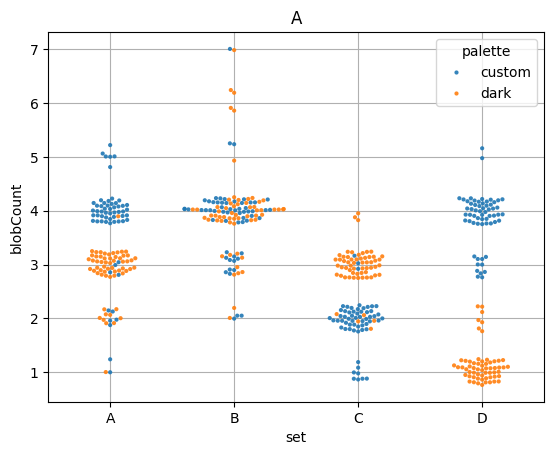

In [ ]:
random.seed(2026)
resultsA = pd.read_csv(pathA)
adjust  =ran_floats = [random.uniform(-.25,.25) for _ in range(480)]
resultsA["blobCount"] = resultsA["blobCount"] + adjust
sns.swarmplot(data=resultsA, x="set", y="blobCount", hue= "palette", alpha = .9, size = 3)
plt.title("A")
plt.grid()
plt.show()


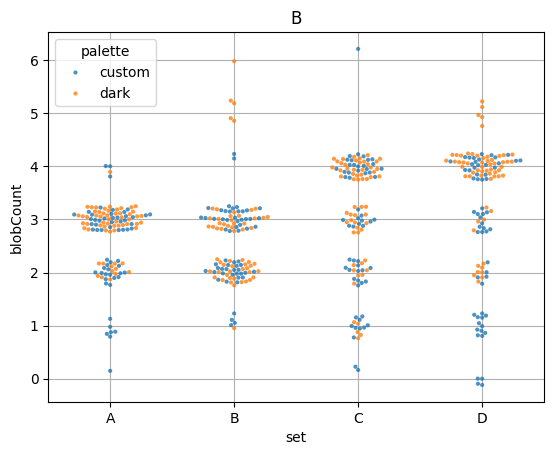

In [ ]:
random.seed(2026)
resultsB = pd.read_csv(pathB)
adjust  =ran_floats = [random.uniform(-.25,.25) for _ in range(480)]
resultsB["blobCount"] = resultsB["blobCount"] + adjust
sns.swarmplot(data=resultsB, x="set", y="blobCount", hue= "palette", alpha = .8, size = 3)
plt.title("B")
plt.grid()
plt.show()

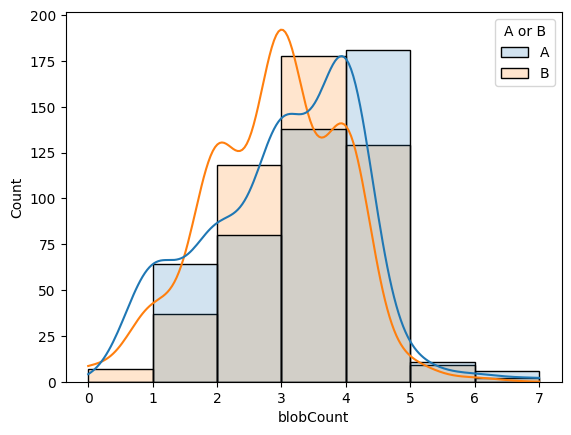

In [75]:
resultsA=pd.read_csv(pathA)
resultsA["A or B"] = "A"
resultsB = pd.read_csv(pathB)
resultsB["A or B"] = "B"
jointResults = pd.concat([resultsA, resultsB])
sns.histplot(data= jointResults, x="blobCount", hue = "A or B", kde=True, binwidth= 1, alpha = .2,kde_kws= {"bw_adjust": 1.3}) 
plt.show()


In [ ]:
path0= "/Users/jdreiling/Desktop/puck/puck/src/puck/dotpipeline/big_picture_0/otsu0.json_results.csv"
path1= "/Users/jdreiling/Desktop/puck/puck/src/puck/dotpipeline/big_picture/otsu1.jston_results.csv"
otsu_0=pd.read_csv(path0)
otsu_1 = pd.read_csv(path1)
best60_0 = otsu_0.sort_values("1", ascending=False).head(60)
best60_1 = otsu_1.sort_values("1", ascending=False).head(60)
best60combos_0=list(best60_0["Unnamed: 0"])
best60combos_1=list(best60_1["Unnamed: 0"])
dictionaryTest = {"0": best60combos_0, "1":best60combos_1}
best60combos = pd.DataFrame.from_dict(dictionaryTest)


In [100]:
best60combos
best60combos.to_csv("/Users/jdreiling/Desktop/puck/puck/src/puck/dotpipeline/best60combos.csv")


In [112]:
(resultsA["closeEnough"]).value_counts()

closeEnough
True     445
False     35
Name: count, dtype: int64

In [113]:
(resultsA["count4"]).value_counts()

count4
False    299
True     181
Name: count, dtype: int64

In [114]:
(resultsA["blobCount"]).value_counts()

blobCount
4    181
3    138
2     80
1     64
5     11
6      4
7      2
Name: count, dtype: int64

In [115]:
resultsB["closeEnough"].value_counts()

closeEnough
True     412
False     68
Name: count, dtype: int64

In [116]:
resultsB["count4"].value_counts()

count4
True     419
False     61
Name: count, dtype: int64

In [118]:
resultsB["blobCount"].value_counts()

blobCount
3    178
4    129
2    118
1     37
5      9
0      7
6      2
Name: count, dtype: int64

In [117]:
resultsB['closeCount4'].value_counts()

closeCount4
False    369
True     111
Name: count, dtype: int64